## Feature Engineering and Model Preparation

Notebook goal:

Prepare the data for ML model by: 
- Selecting modeling features
- Engineering additional predictors 
- Create train/test/val sets

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

In [17]:
df = pd.read_parquet("dataset/processed/open_food_facts_cleaned.parquet")

print("Dataset shape:", df.shape)
df.head(3)

Dataset shape: (223906, 27)


,code,product_name,brands,categories_en,countries_en,ingredients_text,ingredients_analysis_tags,additives_n,additives_tags,nutriscore_score,...,monounsaturated_fat_100g,polyunsaturated_fat_100g,trans_fat_100g,carbohydrates_100g,sugars_100g,added_sugars_100g,starch_100g,fiber_100g,proteins_100g,salt_100g
0,105753078,Bread,NaN,"Plant-based foods and beverages,Plant-based fo...",United States,"Water, white flour, honey, corn syrup, yeast, ...","en:palm-oil-free,en:non-vegan,en:vegetarian-st...",0.0,NaN,NaN,...,1.04,1.25,0.0,14.8,4.0,16.40625,0.087609,1.6,6.4,0.45
1,1065,boisson à l'aloe vera,Herbalife,"Plant-based foods and beverages,Beverages,Meal...","France,Spain","NGREDIENTES: agua, ácido cítrico anhidro, sabo...","en:palm-oil-free,en:vegan-status-unknown,en:ve...",3.0,"en:e211,en:e330,en:e955",NaN,...,1.04,1.25,0.0,3.0,0.0,0.00000,0.087609,0.0,0.0,0.10
2,112302621,Potiron et vermicelles,Liebig,"Plant-based foods and beverages,Plant-based fo...",France,"eau, légumes 30% (potiron 17%, carotte, jus de...","en:palm-oil-free,en:non-vegan,en:vegetarian-st...",1.0,en:e14xx,3.0,...,1.04,1.25,0.0,4.5,1.7,0.35000,0.087609,0.8,0.7,0.70


## Feature Selection

We select the key numerical features that represent nutritional composition and processing indicators. These features will be used as inputs to the machine learning models, while `nova_group` is used as the target variable.

In [18]:
# define our target
TARGET = "nova_group"

# define our numeric features
NUMERIC_FEATURES = [
    "energy_100g",
    "fat_100g",
    "carbohydrates_100g",
    "sugars_100g",
    "fiber_100g",
    "proteins_100g",
    "salt_100g",
    "saturated_fat_100g",
    "additives_n",
    "trans_fat_100g",
    "added_sugars_100g",
    "monounsaturated_fat_100g",
    "polyunsaturated_fat_100g",
    "starch_100g",
    "nutriscore_score",
]

# only keep features that exist in the loaded parquet
# (new columns require re-running the EDA notebook after regenerating light.csv)
available = [c for c in NUMERIC_FEATURES if c in df.columns]
missing = [c for c in NUMERIC_FEATURES if c not in df.columns]
if missing:
    print(f"Note: {len(missing)} features not in dataset (re-run EDA to add): {missing}")
NUMERIC_FEATURES = available

# create our modeling dataframe
df_model = df[NUMERIC_FEATURES + [TARGET]].copy()

# validate target: drop rows with missing or unexpected nova_group values
valid_nova = {1, 2, 3, 4}
n_before = len(df_model)
df_model = df_model[df_model[TARGET].isin(valid_nova)]
print(f"Rows dropped (invalid/missing nova_group): {n_before - len(df_model):,}")

# drop rows where ALL numeric features are NaN (no usable data)
n_before = len(df_model)
df_model = df_model.dropna(subset=NUMERIC_FEATURES, how="all")
print(f"Rows dropped (all features NaN): {n_before - len(df_model):,}")

# fill remaining NaN in sparse columns with 0 (absence of data = no recorded value)
sparse_cols = [
    c for c in [
        "trans_fat_100g",
        "added_sugars_100g",
        "monounsaturated_fat_100g",
        "polyunsaturated_fat_100g",
        "starch_100g",
    ] if c in NUMERIC_FEATURES
]
if sparse_cols:
    df_model[sparse_cols] = df_model[sparse_cols].fillna(0)

# fill nutriscore_score NaNs with median
if "nutriscore_score" in NUMERIC_FEATURES and df_model["nutriscore_score"].isna().any():
    df_model["nutriscore_score"] = df_model["nutriscore_score"].fillna(
        df_model["nutriscore_score"].median()
    )

# fill any remaining NaNs in core nutrient columns with their median
core_cols = [c for c in NUMERIC_FEATURES if c not in sparse_cols and c != "nutriscore_score"]
for col in core_cols:
    if df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(df_model[col].median())

# verify no NaN remains
assert df_model[NUMERIC_FEATURES].isna().sum().sum() == 0, "NaN values remain in features!"
assert df_model[TARGET].isna().sum() == 0, "NaN values remain in target!"

print(f"\nFeatures used ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Model dataset shape: {df_model.shape}")
print(f"NaN remaining: {df_model.isna().sum().sum()}")
df_model.head(3)

Rows dropped (invalid/missing nova_group): 0
Rows dropped (all features NaN): 0

Features used (15): ['energy_100g', 'fat_100g', 'carbohydrates_100g', 'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g', 'saturated_fat_100g', 'additives_n', 'trans_fat_100g', 'added_sugars_100g', 'monounsaturated_fat_100g', 'polyunsaturated_fat_100g', 'starch_100g', 'nutriscore_score']
Model dataset shape: (223906, 16)
NaN remaining: 0


,energy_100g,fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,saturated_fat_100g,additives_n,trans_fat_100g,added_sugars_100g,monounsaturated_fat_100g,polyunsaturated_fat_100g,starch_100g,nutriscore_score,nova_group
0,1032.4,6.0,14.8,4.0,1.6,6.4,0.45,1.785714,0.0,0.0,16.40625,1.04,1.25,0.087609,8.0,3
1,51.0,0.0,3.0,0.0,0.0,0.0,0.10,0.000000,3.0,0.0,0.00000,1.04,1.25,0.087609,8.0,4
2,109.6,0.4,4.5,1.7,0.8,0.7,0.70,0.200000,1.0,0.0,0.35000,1.04,1.25,0.087609,3.0,4


## Feature Engineering

To improve our model performance, we create the additional features below. 
- sugar_fiber_ratio
- fat_protein_ratio
- additives_per_energy
- trans_fat_ratio — trans fat as a share of total fat (marker of hydrogenation)
- unsaturated_fat_ratio — mono+poly unsaturated fat share of total fat

In [19]:
# avoid division by zero, in case any of our values are zero
# from the nutrional label. A small epsilon will take care of this
epsilon = 1e-5

# sugar to fiber ratio (processed foods tend to be high sugar, low fiber)
df_model["sugar_fiber_ratio"] = df_model["sugars_100g"] / (df_model["fiber_100g"] + epsilon)

# fat to protein ratio (helps distinguish nutrient balance)
# again, processed foods tend of have higher fat relative to protein content 
df_model["fat_protein_ratio"] = df_model["fat_100g"] / (df_model["proteins_100g"] + epsilon)

# additive density relative to calories
# higher value can indicate many additives for the caloric count
df_model["additives_per_energy"] = df_model["additives_n"] / (df_model["energy_100g"] + 1)

# trans fat as a share of total fat — marker of industrial hydrogenation
if "trans_fat_100g" in df_model.columns:
    df_model["trans_fat_ratio"] = df_model["trans_fat_100g"] / (df_model["fat_100g"] + epsilon)

# unsaturated fat share of total fat — natural fats vs processed
if "monounsaturated_fat_100g" in df_model.columns and "polyunsaturated_fat_100g" in df_model.columns:
    df_model["unsaturated_fat_ratio"] = (
        df_model["monounsaturated_fat_100g"] + df_model["polyunsaturated_fat_100g"]
    ) / (df_model["fat_100g"] + epsilon)

# cap engineered ratios at the 99th percentile to prevent extreme outliers
# from dominating the model (near-zero denominators can produce huge values)
ENGINEERED_RATIOS = [
    c for c in [
        "sugar_fiber_ratio",
        "fat_protein_ratio",
        "additives_per_energy",
        "trans_fat_ratio",
        "unsaturated_fat_ratio",
    ] if c in df_model.columns
]

for col in ENGINEERED_RATIOS:
    cap = df_model[col].quantile(0.99)
    n_capped = (df_model[col] > cap).sum()
    df_model[col] = df_model[col].clip(upper=cap)
    if n_capped > 0:
        print(f"  {col}: capped {n_capped:,} values at {cap:.2f}")

print(f"\nUpdated dataset shape: {df_model.shape}")
df_model.head(3)

  sugar_fiber_ratio: capped 2,208 values at 5900000.00
  additives_per_energy: capped 2,237 values at 0.32
  trans_fat_ratio: capped 1,173 values at 0.00
  unsaturated_fat_ratio: capped 6 values at 229000.00

Updated dataset shape: (223906, 21)


,energy_100g,fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,saturated_fat_100g,additives_n,trans_fat_100g,...,monounsaturated_fat_100g,polyunsaturated_fat_100g,starch_100g,nutriscore_score,nova_group,sugar_fiber_ratio,fat_protein_ratio,additives_per_energy,trans_fat_ratio,unsaturated_fat_ratio
0,1032.4,6.0,14.8,4.0,1.6,6.4,0.45,1.785714,0.0,0.0,...,1.04,1.25,0.087609,8.0,3,2.499984,0.937499,0.000000,0.0,0.381666
1,51.0,0.0,3.0,0.0,0.0,0.0,0.10,0.000000,3.0,0.0,...,1.04,1.25,0.087609,8.0,4,0.000000,0.000000,0.057692,0.0,229000.000000
2,109.6,0.4,4.5,1.7,0.8,0.7,0.70,0.200000,1.0,0.0,...,1.04,1.25,0.087609,3.0,4,2.124973,0.571420,0.009042,0.0,5.724857


## Post-Engineering Correlation Check

After creating engineered features, we verify that no pair of features is excessively correlated. Highly correlated features (|r| > 0.85) would add redundancy rather than signal and could potentially be dropped.

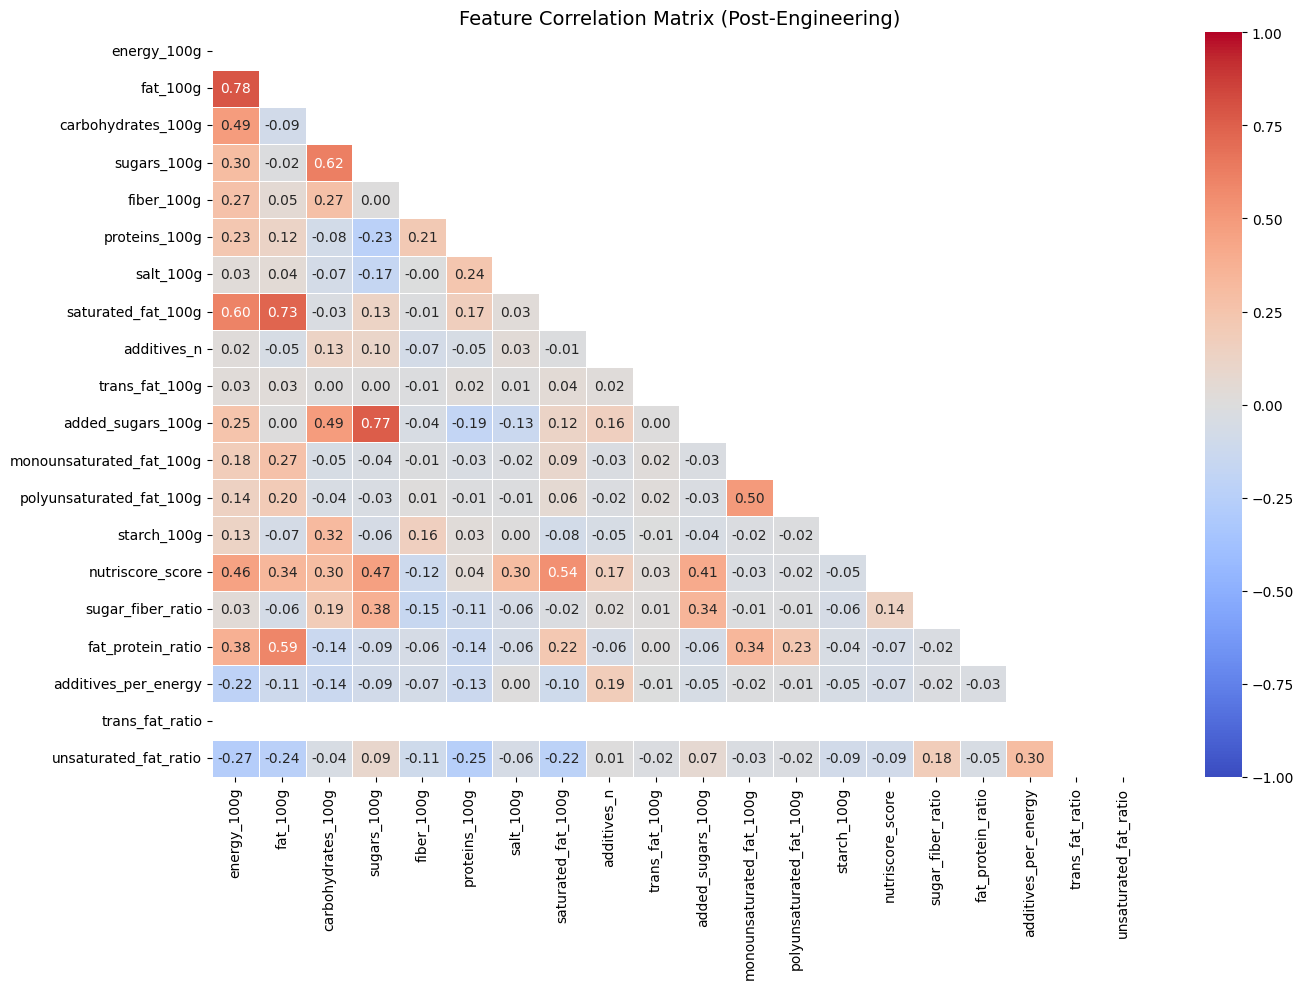

No feature pairs exceed |r| = 0.85.


In [20]:
# post-engineering correlation check to detect redundant features
corr = df_model.drop(columns=[TARGET]).corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix (Post-Engineering)", fontsize=14)
plt.tight_layout()
plt.show()

# flag highly correlated pairs (|r| > 0.85)
high_corr = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append((cols[i], cols[j], round(r, 3)))

if high_corr:
    print("Highly correlated pairs (|r| > 0.85):")
    for a, b, r in high_corr:
        print(f"  {a} <-> {b}: {r}")
else:
    print("No feature pairs exceed |r| = 0.85.")

## Class Distribution

Before splitting, we check the target variable distribution to understand the class imbalance severity. This informs whether class weights are needed during model training.

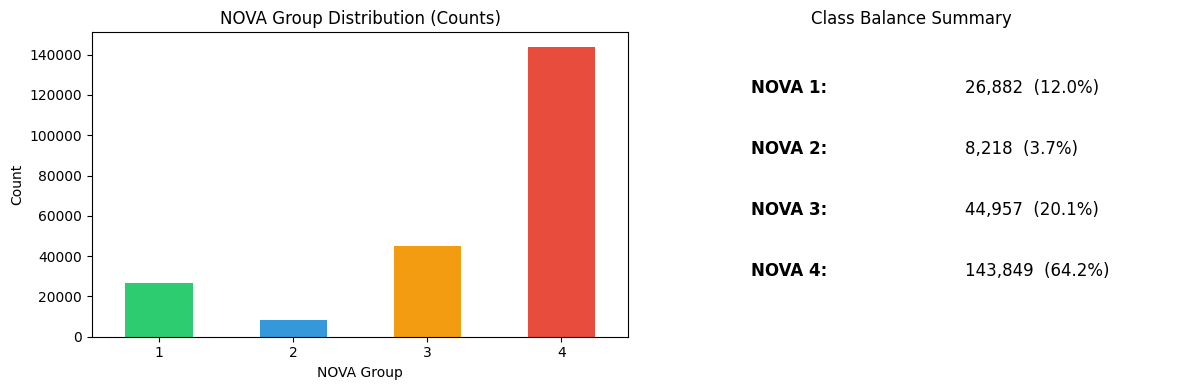

Class weights (0-indexed for XGBoost): {0: 2.082, 1: 6.811, 2: 1.245, 3: 0.389}


In [21]:
# class distribution
class_counts = df_model[TARGET].value_counts().sort_index()
class_pct = (class_counts / len(df_model) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart
class_counts.plot(kind="bar", ax=axes[0], color=["#2ecc71", "#3498db", "#f39c12", "#e74c3c"])
axes[0].set_title("NOVA Group Distribution (Counts)")
axes[0].set_xlabel("NOVA Group")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# percentage table
for i, (nova, count) in enumerate(class_counts.items()):
    axes[1].text(0.2, 0.8 - i * 0.2, f"NOVA {nova}:", fontsize=12, fontweight="bold",
                 transform=axes[1].transAxes)
    axes[1].text(0.6, 0.8 - i * 0.2, f"{count:,}  ({class_pct[nova]}%)", fontsize=12,
                 transform=axes[1].transAxes)
axes[1].axis("off")
axes[1].set_title("Class Balance Summary")

plt.tight_layout()
plt.show()

# compute class weights for XGBoost (inverse frequency)
total = len(df_model)
n_classes = len(class_counts)
class_weights = {int(k - 1): total / (n_classes * v) for k, v in class_counts.items()}
print("Class weights (0-indexed for XGBoost):", {k: round(v, 3) for k, v in class_weights.items()})

## Train/Test/Validation Split

In [22]:

# Split features and target
X = df_model.drop(columns=["nova_group"])
y = df_model["nova_group"]

# doing this to satisfy XGBoost's requirement of needing to start from 0
y = y - 1

# Step 1: Train (60%) + Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

# Step 2: Split Temp into Validation (20%) and Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (134343, 20)
Validation shape: (44781, 20)
Test shape: (44782, 20)


## Feature Scaling

- Feature scaling is applied after splitting our data, so that statistics from the training set do not leak into the validation or test sets. 
- Standardization is required because we will use a Deep Learning model to perform anomaly detection of the processed foods. 

In [23]:
# initialize scaler
scaler = StandardScaler()

# fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (134343, 20)
Scaled validation shape: (44781, 20)
Scaled test shape: (44782, 20)


## XGBoost Baseline Model

- XGBoost classifier trained as supervised baseline for predicting NOVA processing groups. 
- Because the model handles non-linear relations, it is ideal for our complex nutrient interactions.
- XGBoost is tree-based and invariant to feature scaling, so we use the **unscaled** training data here. The scaled data is reserved for the deep learning anomaly detection model.
- Class weights (`sample_weight`) are applied to address the NOVA 4 class imbalance identified above.

In [24]:
# compute per-sample weights from class_weights dict
train_sample_weights = y_train.map(class_weights)

# initial baseline model with class-weight-aware training
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42,
)

xgb_model.fit(X_train, y_train, sample_weight=train_sample_weights)

y_val_pred = xgb_model.predict(X_val)

print("Baseline XGBoost model trained.")

Baseline XGBoost model trained.


## Model Evaluation

Classification report and confusion matrix to assess baseline XGBoost performance, particularly across imbalanced NOVA groups.

Validation Set — Classification Report
              precision    recall  f1-score   support

      NOVA 1       0.76      0.93      0.84      5376
      NOVA 2       0.78      0.94      0.85      1644
      NOVA 3       0.64      0.81      0.72      8991
      NOVA 4       0.96      0.83      0.89     28770

    accuracy                           0.84     44781
   macro avg       0.79      0.88      0.83     44781
weighted avg       0.87      0.84      0.85     44781

Overall Validation Accuracy: 0.8435


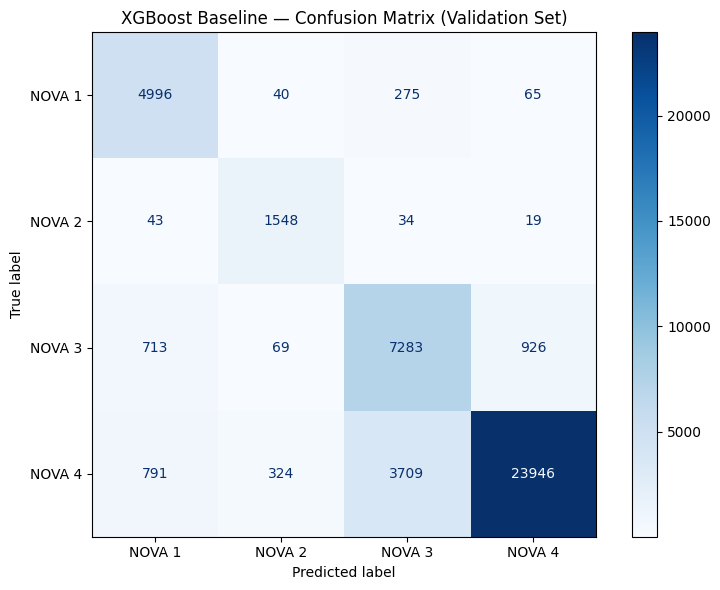

  NOVA 1 accuracy: 0.929
  NOVA 2 accuracy: 0.942
  NOVA 3 accuracy: 0.810
  NOVA 4 accuracy: 0.832


In [ ]:
# NOVA labels (0-indexed to match y encoding)
nova_labels = ["NOVA 1", "NOVA 2", "NOVA 3", "NOVA 4"]

# classification report
print("Validation Set — Classification Report")
print(classification_report(y_val, y_val_pred, target_names=nova_labels))

# accuracy
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Overall Validation Accuracy: {val_acc:.4f}")

# confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nova_labels)
disp.plot(cmap="Blues", ax=ax, values_format="d")
ax.set_title("XGBoost Baseline — Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

# per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for label, acc in zip(nova_labels, per_class_acc):
    print(f"  {label} accuracy: {acc:.3f}")

## Feature Importance

XGBoost feature importance shows which nutritional features and engineered ratios contribute most to predicting NOVA processing groups. This helps us understand the model's decision-making and validates that the engineered features add predictive value.

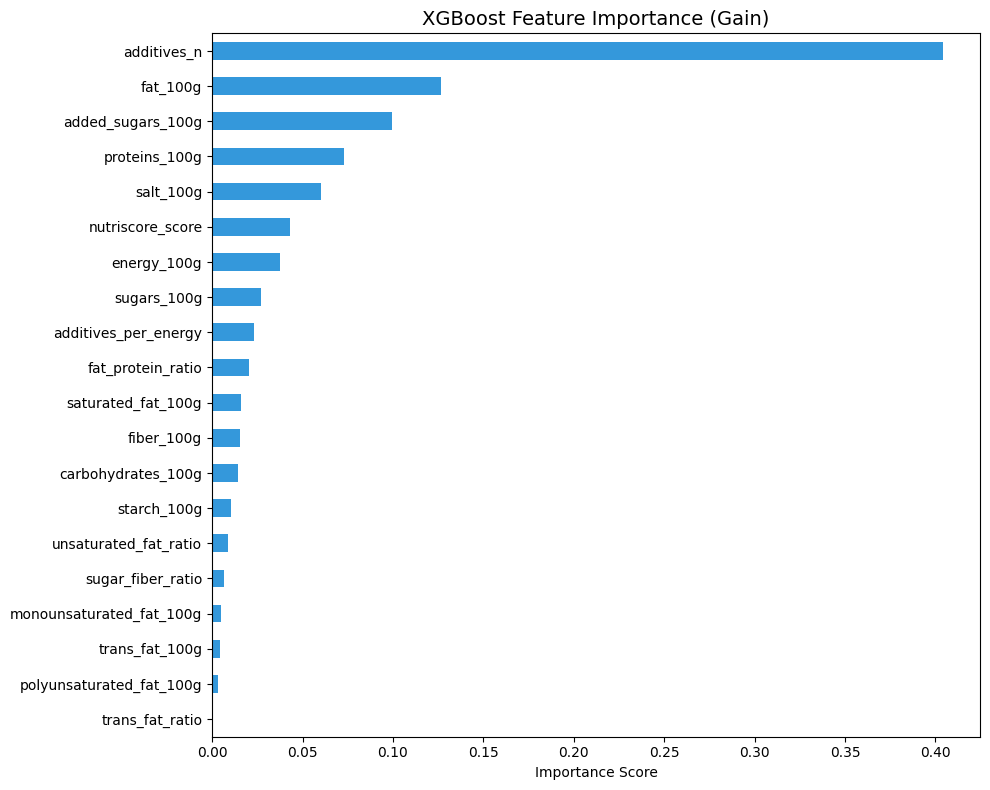

Top 10 features:
  additives_n: 0.4044
  fat_100g: 0.1265
  added_sugars_100g: 0.0995
  proteins_100g: 0.0731
  salt_100g: 0.0604
  nutriscore_score: 0.0433
  energy_100g: 0.0376
  sugars_100g: 0.0272
  additives_per_energy: 0.0234
  fat_protein_ratio: 0.0201


In [26]:
# feature importance from XGBoost (gain-based)
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("XGBoost Feature Importance (Gain)", fontsize=14)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

# top 10 features
print("Top 10 features:")
for feat, score in importance.tail(10).iloc[::-1].items():
    print(f"  {feat}: {score:.4f}")

## Save Artifacts

Save the trained model, scaler, and train/val/test splits so downstream notebooks (anomaly detection, evaluation) can load them without re-running this pipeline.

In [27]:
# create output directory
ARTIFACTS_DIR = "models"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# save XGBoost model
xgb_model.save_model(os.path.join(ARTIFACTS_DIR, "xgb_baseline.json"))
print("Saved: xgb_baseline.json")

# save scaler
joblib.dump(scaler, os.path.join(ARTIFACTS_DIR, "standard_scaler.joblib"))
print("Saved: standard_scaler.joblib")

# save train/val/test splits (scaled and unscaled)
splits = {
    "X_train": X_train, "X_val": X_val, "X_test": X_test,
    "y_train": y_train, "y_val": y_val, "y_test": y_test,
    "X_train_scaled": X_train_scaled,
    "X_val_scaled": X_val_scaled,
    "X_test_scaled": X_test_scaled,
    "feature_names": list(X_train.columns),
    "class_weights": class_weights,
}
joblib.dump(splits, os.path.join(ARTIFACTS_DIR, "data_splits.joblib"))
print("Saved: data_splits.joblib")

print(f"All artifacts saved to '{ARTIFACTS_DIR}/' directory.")

Saved: xgb_baseline.json
Saved: standard_scaler.joblib
Saved: data_splits.joblib
All artifacts saved to 'models/' directory.
